In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

In [2]:
df=pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df['species'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [4]:
df.duplicated().sum()

np.int64(3)

In [5]:
df = df.drop_duplicates()
df.shape

(147, 5)

In [6]:
df["species"].value_counts()


species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

In [7]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

SPECIES DISTRIBUTION

C:\Users\Krishna Rajoo\AppData\Local\Temp\ipykernel_24492\2973084052.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


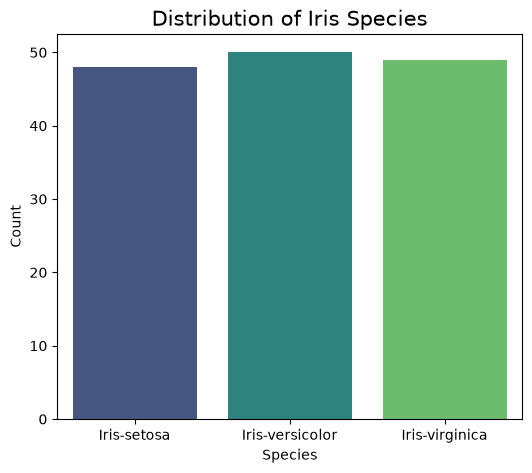

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='species',
    data=df,
    palette='viridis'
)

plt.title("Distribution of Iris Species", fontsize=15)
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

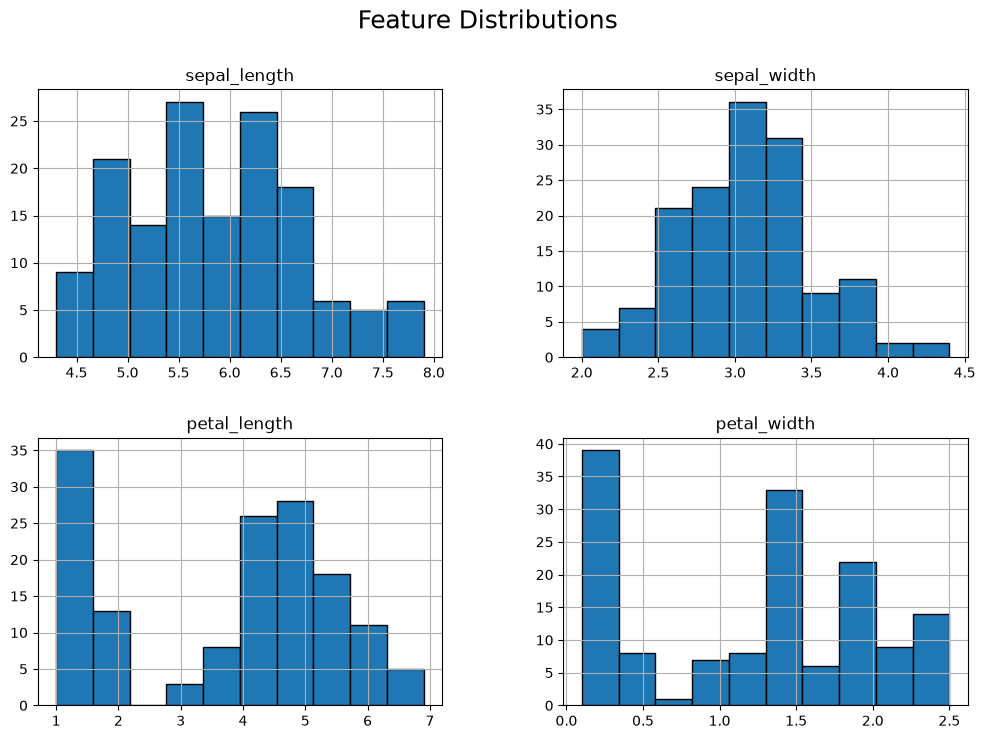

In [9]:
df.hist(figsize=(12,8), edgecolor='black')

plt.suptitle("Feature Distributions", fontsize=18)

plt.show()

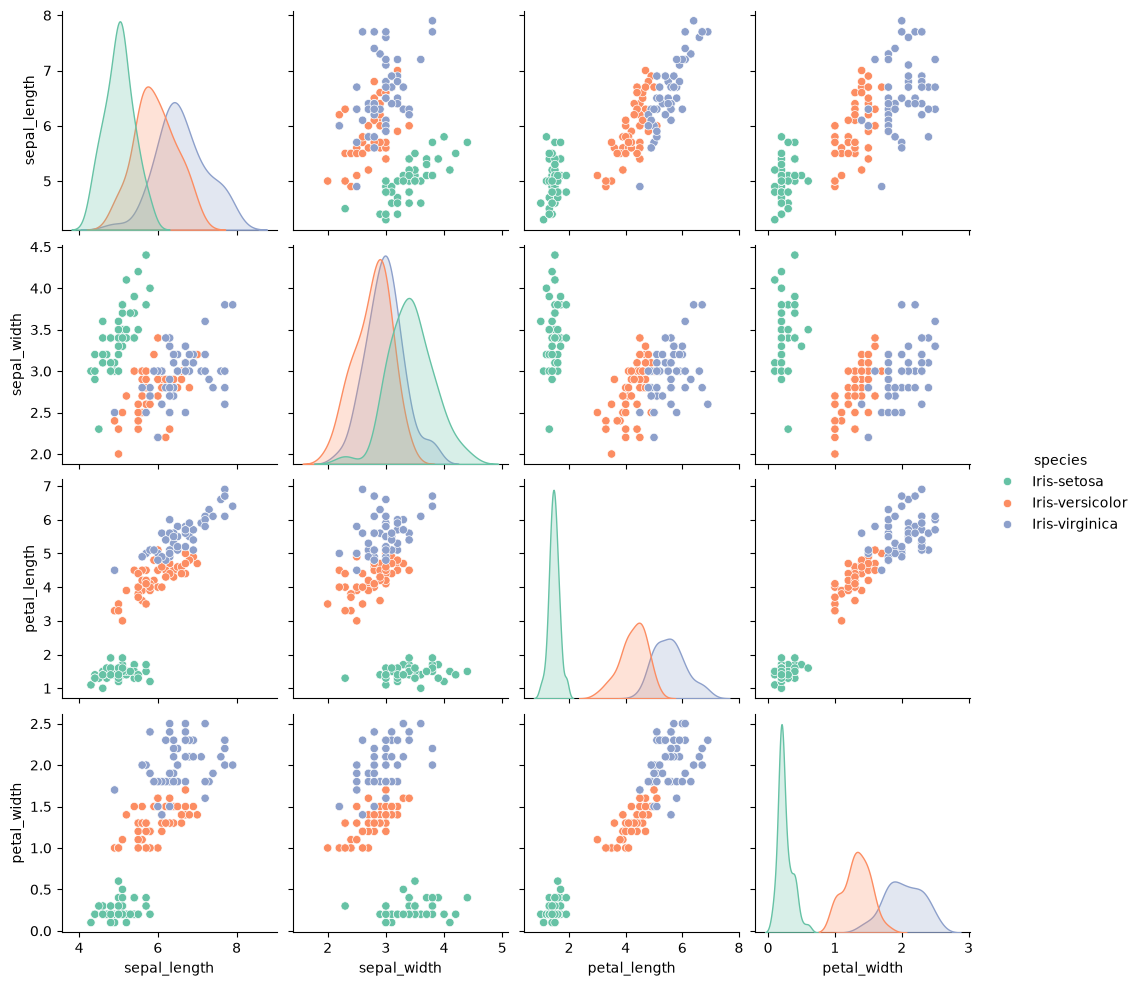

In [10]:
sns.pairplot(
    df,
    hue='species',
    palette='Set2'
)

plt.show()

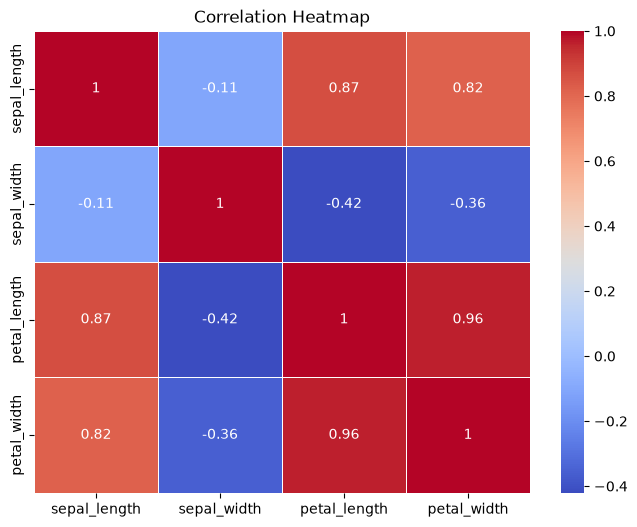

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

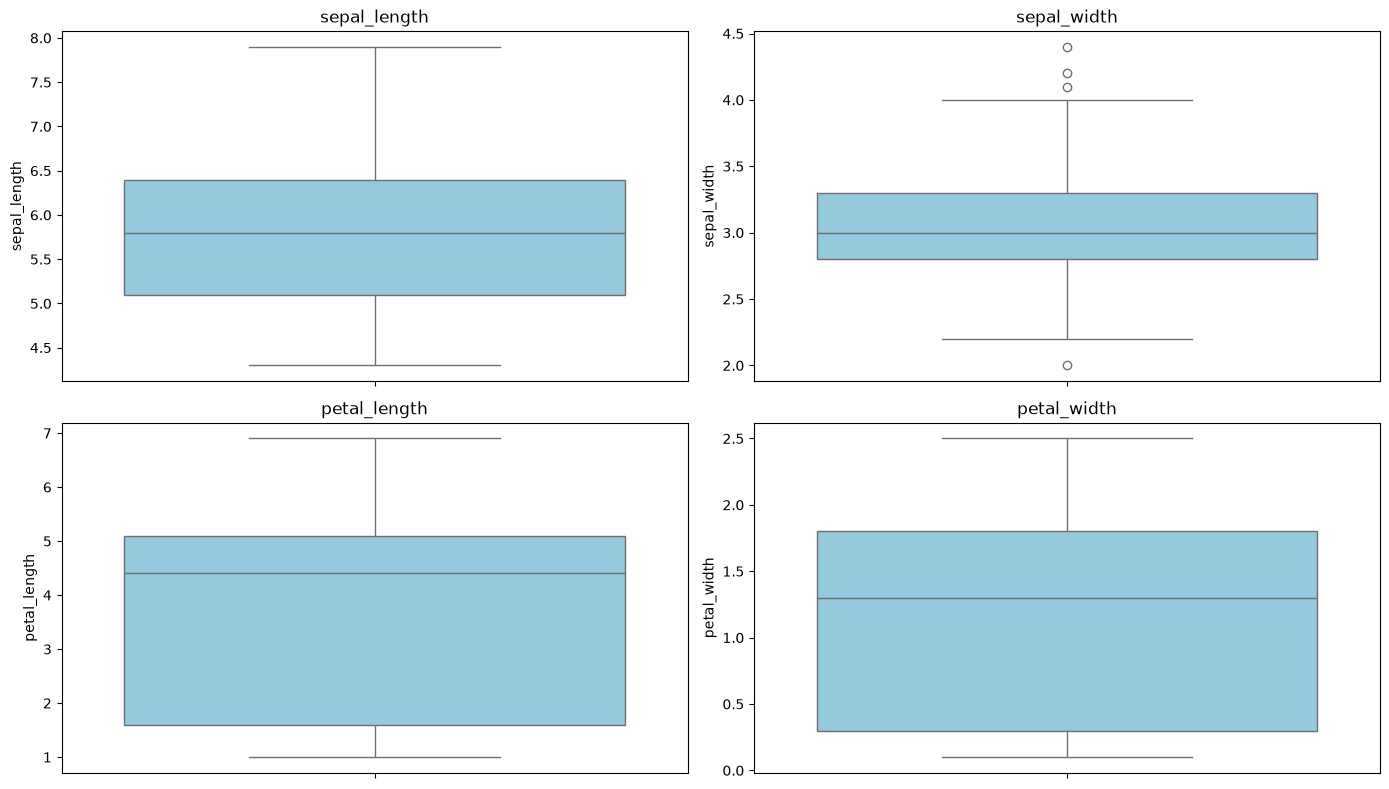

In [12]:
features = df.columns[:-1]

plt.figure(figsize=(14,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)

    sns.boxplot(
        y=df[feature],
        color='skyblue'
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

C:\Users\Krishna Rajoo\AppData\Local\Temp\ipykernel_24492\3293202716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Krishna Rajoo\AppData\Local\Temp\ipykernel_24492\3293202716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Krishna Rajoo\AppData\Local\Temp\ipykernel_24492\3293202716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Krishna Rajoo\AppData\Local\Temp\ipykernel_24492\3293202716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

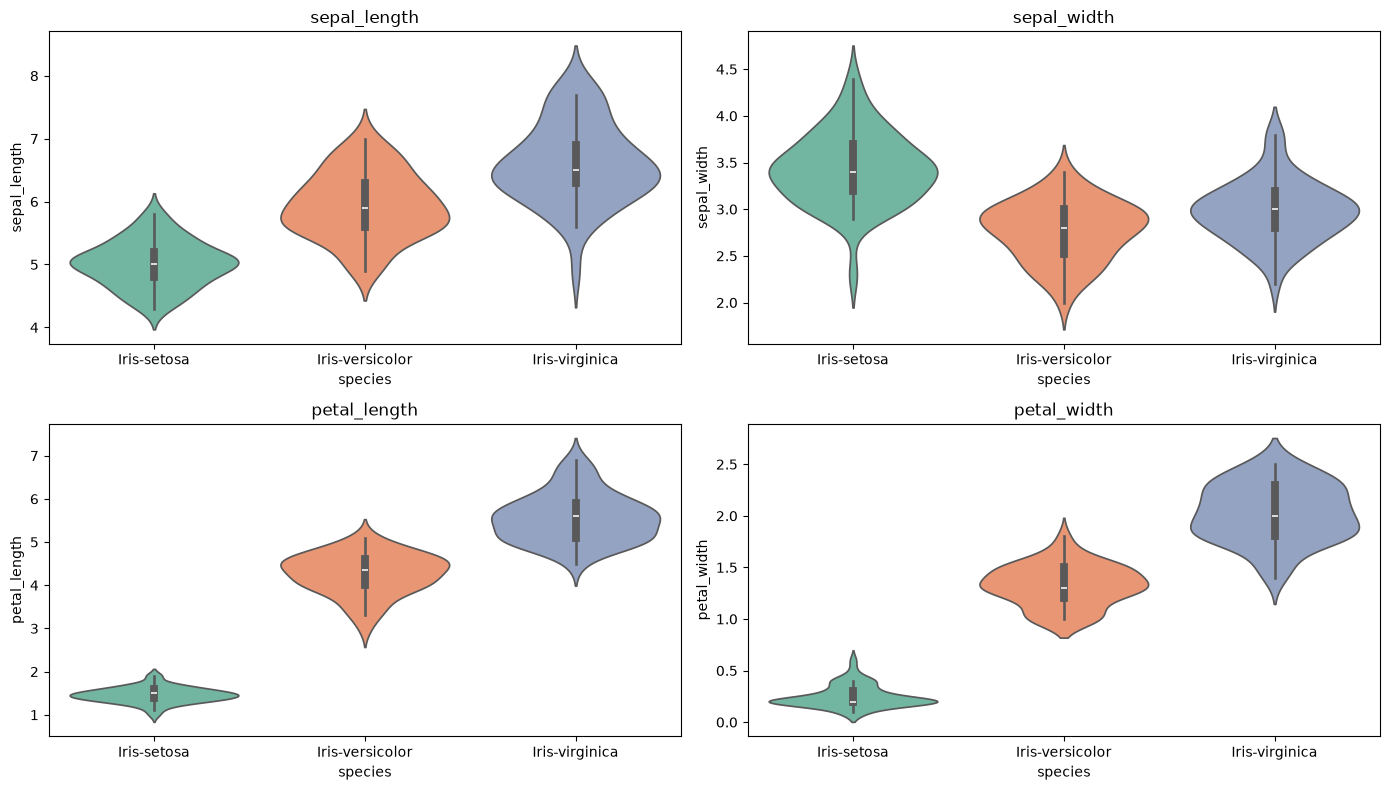

In [13]:
features = df.columns[:-1]

plt.figure(figsize=(14,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)

    sns.violinplot(
        x='species',
        y=feature,
        data=df,
        palette='Set2'
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

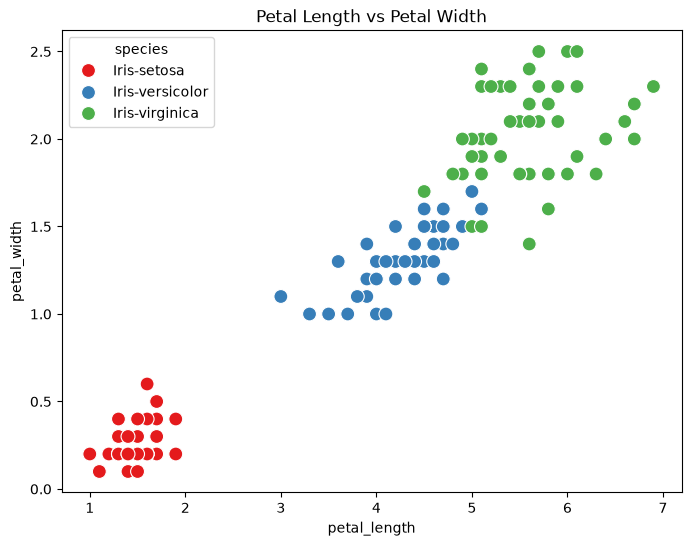

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df,
    palette='Set1',
    s=100
)

plt.title("Petal Length vs Petal Width")

plt.show()

DATA PREPROCESSING

In [15]:
encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
print(encoder.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [17]:
mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(mapping)

{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [18]:
X = df.drop("species", axis=1)

y = df["species"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (147, 4)
Target Shape : (147,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (117, 4)
Testing Samples : (30, 4)


In [20]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [21]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


In [22]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [23]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9333333333333333


In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [25]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9666666666666667


In [26]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy
0,Logistic Regression,0.966667
1,Random Forest,0.966667
2,Decision Tree,0.933333


C:\Users\Krishna Rajoo\AppData\Local\Temp\ipykernel_24492\1585803603.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


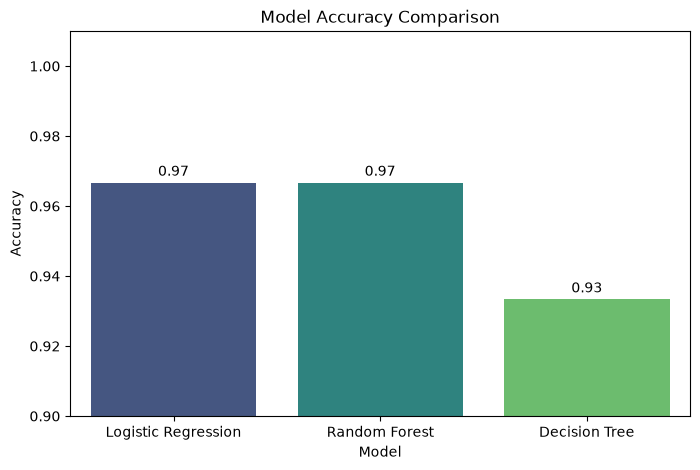

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0.9, 1.01)

for index, value in enumerate(results["Accuracy"]):
    plt.text(index, value + 0.002, f"{value:.2f}", ha="center")

plt.show()

In [28]:
best_model = rf_model
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 96.67%


In [29]:
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [30]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


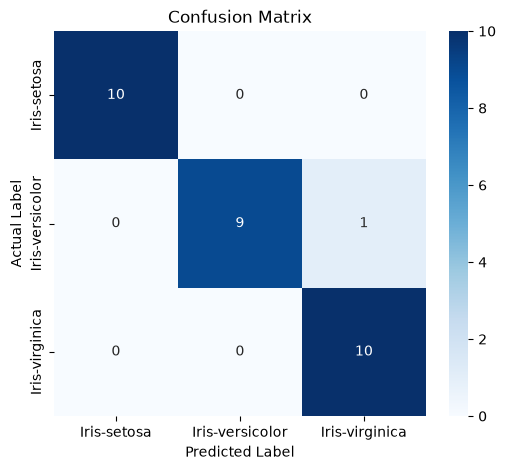

In [31]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,petal_length,0.443075
3,petal_width,0.414662
0,sepal_length,0.121489
1,sepal_width,0.020774


C:\Users\Krishna Rajoo\AppData\Local\Temp\ipykernel_24492\3298044445.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


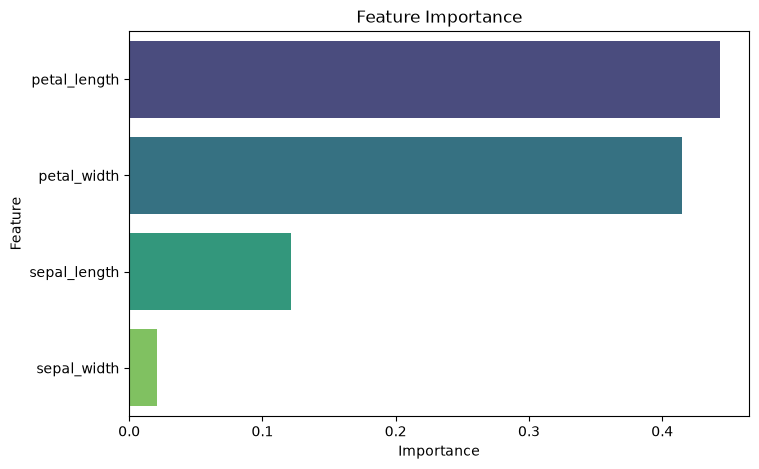

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette="viridis"
)

plt.title("Feature Importance")

plt.show()

In [34]:
joblib.dump(best_model, "iris_model.pkl")

['iris_model.pkl']

In [35]:
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [36]:
model = joblib.load("iris_model.pkl")
encoder = joblib.load("label_encoder.pkl")

In [37]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

flower = encoder.inverse_transform(prediction)

print("Predicted Flower:", flower[0])

Predicted Flower: Iris-setosa


c:\Users\Krishna Rajoo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
